PROGRAMMING APPROACH:

1.Import required libraries.

2.Import required dataset.

3.Preprocessing.

4.Assign dependent and independent variable.

5.Split the data into trainig and testing.

6.Feature engineering.

7.Fit the model.

8.Compute and visualize.

9.Evaluation.

In [2]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
#simple regressing program:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as msc



In [4]:

data=pd.read_csv("C:/Users/ELCOT/Downloads/income.csv")
data.head()

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    22 non-null     str  
 1   Age     22 non-null     int64
 2   Income  22 non-null     int64
dtypes: int64(2), str(1)
memory usage: 660.0 bytes


In [6]:
data.isnull()

,Name,Age,Income
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [7]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
dtype: bool

In [8]:
x=data.iloc[:,1:2]
y=data.iloc[:,-1]
print(x.shape,y.shape)

(22, 1) (22,)


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
display(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(17, 1)

(17,)

(5, 1)

(5,)

In [10]:
lin_model=LinearRegression()
lin_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
pred=lin_model.predict(x_test)
print(pred[:10])

[ 65819.69486824  98918.16920943 119604.71567268 111330.09708738
  69957.00416089]


In [12]:
error=msc(pred,y_test)
error

1951777273.146981

In [15]:
import pickle

# Load model
p = pickle.load(open('income.pkl', 'rb'))

# Get user input
Age = int(input("Enter your Age: "))

# Prediction
result = p.predict([[Age]])

# Print prediction
print("Predicted Income:", result[0])

Predicted Income: 53407.766990291275


C:\Users\ELCOT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


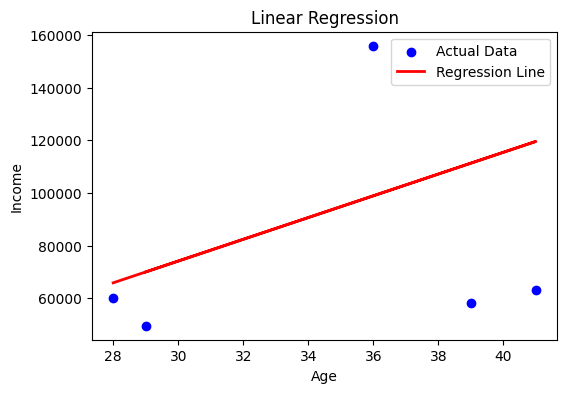

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(x_test, y_test, color='blue', label='Actual Data')
plt.plot(x_test, pred, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()

plt.show()

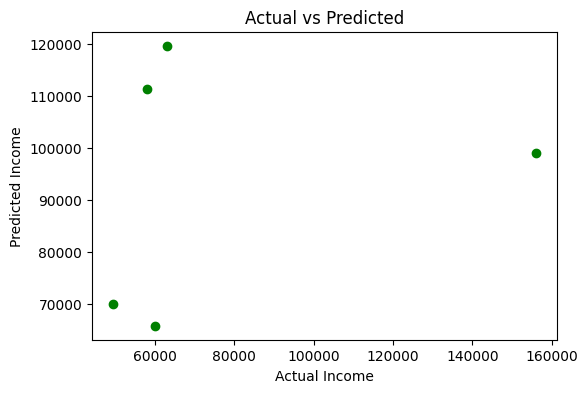

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(y_test, pred, color='green')

plt.title("Actual vs Predicted")
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")

plt.show()